In [10]:
#Cell 1 — Imports & Load Data:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

plt.style.use('dark_background')

# Load clean data
opened = pd.read_csv(r"C:\Users\zaidr\OneDrive\Desktop\Projects\fca-complaints\data\opened_clean.csv")
upheld = pd.read_csv(r"C:\Users\zaidr\OneDrive\Desktop\Projects\fca-complaints\data\upheld_clean.csv")

# Convert numeric columns
product_cols = [
    'Banking and credit cards', 'Decumulation & pensions',
    'Home finance', 'Insurance & pure protection', 'Investments'
]
for col in product_cols:
    opened[col] = pd.to_numeric(opened[col], errors='coerce')
    upheld[col] = pd.to_numeric(upheld[col], errors='coerce')

opened['total_complaints'] = pd.to_numeric(opened['total_complaints'], errors='coerce')

print(f"Opened shape: {opened.shape}")
print(f"Upheld shape: {upheld.shape}")
print(f"Sectors: {opened['sector'].value_counts()}")
print("Sample upheld values:")
print(upheld[product_cols].head(10))

Opened shape: (1554, 13)
Upheld shape: (1558, 13)
Sectors: sector
Insurance             874
Banking               386
Mortgage & Lending    153
Investments           119
Energy & Utilities     22
Name: count, dtype: int64
Sample upheld values:
   Banking and credit cards  Decumulation & pensions  Home finance  \
0                    100.00                      NaN         59.82   
1                       NaN                      NaN           NaN   
2                       NaN                      NaN           NaN   
3                     16.75                      NaN           NaN   
4                       NaN                      NaN           NaN   
5                       NaN                      NaN           NaN   
6                       NaN                      NaN           NaN   
7                       NaN                      NaN           NaN   
8                     60.12                      NaN         70.97   
9                       NaN                      NaN    

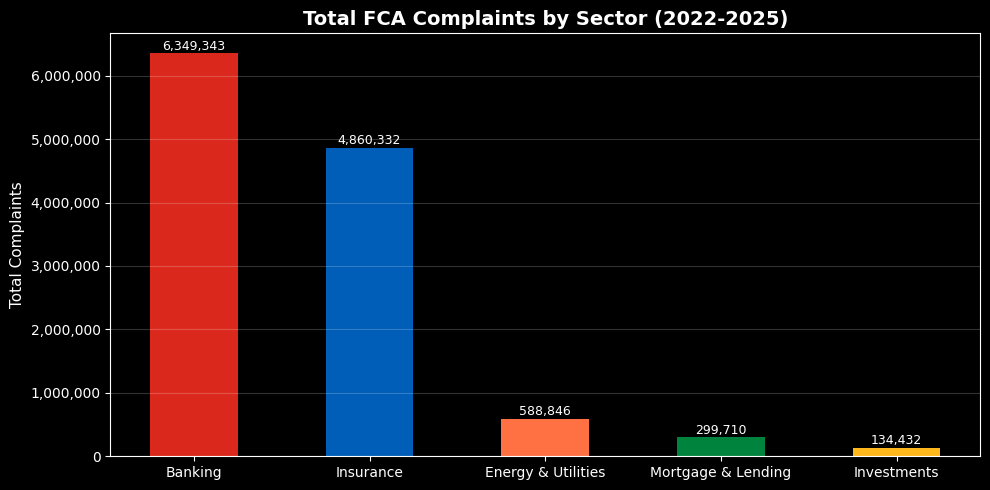

            sector  total_complaints
           Banking         6349343.0
         Insurance         4860332.0
Energy & Utilities          588846.0
Mortgage & Lending          299710.0
       Investments          134432.0


In [3]:
#Complaints by Sector:
sector_totals = opened.groupby('sector')['total_complaints'].sum().sort_values(ascending=False).reset_index()

colors = ['#DA291C', '#005EB8', '#FF7043', '#00843D', '#FFB81C']

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(sector_totals['sector'], sector_totals['total_complaints'],
              color=colors, edgecolor='none', width=0.5)
for bar, val in zip(bars, sector_totals['total_complaints']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10000,
            f'{val:,.0f}', ha='center', va='bottom', fontsize=9, color='white')
ax.set_title('Total FCA Complaints by Sector (2022-2025)', fontsize=14, fontweight='bold')
ax.set_ylabel('Total Complaints', fontsize=11)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, p: f'{x:,.0f}'))
ax.grid(True, alpha=0.2, axis='y')
plt.tight_layout()
plt.savefig(r"C:\Users\zaidr\OneDrive\Desktop\Projects\fca-complaints\figures\sector_totals.png",
            dpi=150, bbox_inches='tight')
plt.show()

print(sector_totals.to_string(index=False))

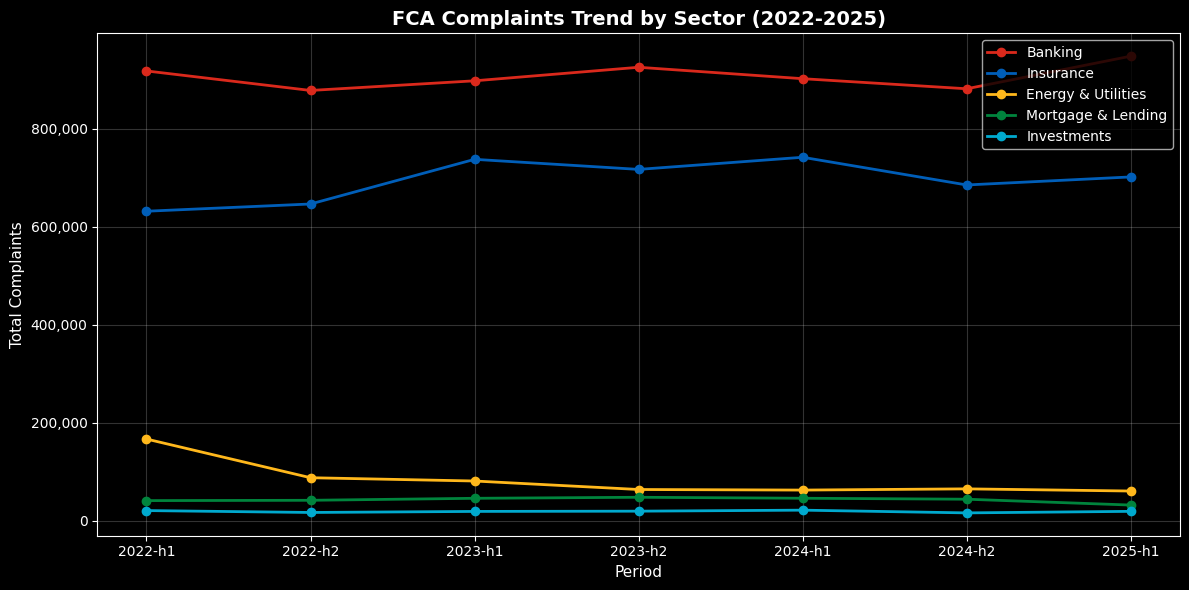

In [5]:
#Complaints Trend by Sector:
trend = opened.groupby(['period', 'sector'])['total_complaints'].sum().reset_index()
trend = trend.sort_values('period')

sector_colors = {
    'Banking': '#DA291C',
    'Insurance': '#005EB8',
    'Energy & Utilities': '#FFB81C',
    'Mortgage & Lending': '#00843D',
    'Investments': '#00A9CE'
}

fig, ax = plt.subplots(figsize=(12, 6))
for sector, color in sector_colors.items():
    sector_data = trend[trend['sector'] == sector]
    ax.plot(sector_data['period'], sector_data['total_complaints'],
            marker='o', linewidth=2, label=sector, color=color)

ax.set_title('FCA Complaints Trend by Sector (2022-2025)', fontsize=14, fontweight='bold')
ax.set_xlabel('Period', fontsize=11)
ax.set_ylabel('Total Complaints', fontsize=11)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, p: f'{x:,.0f}'))
ax.legend(loc='upper right')
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig(r"C:\Users\zaidr\OneDrive\Desktop\Projects\fca-complaints\figures\sector_trend.png",
            dpi=150, bbox_inches='tight')
plt.show()

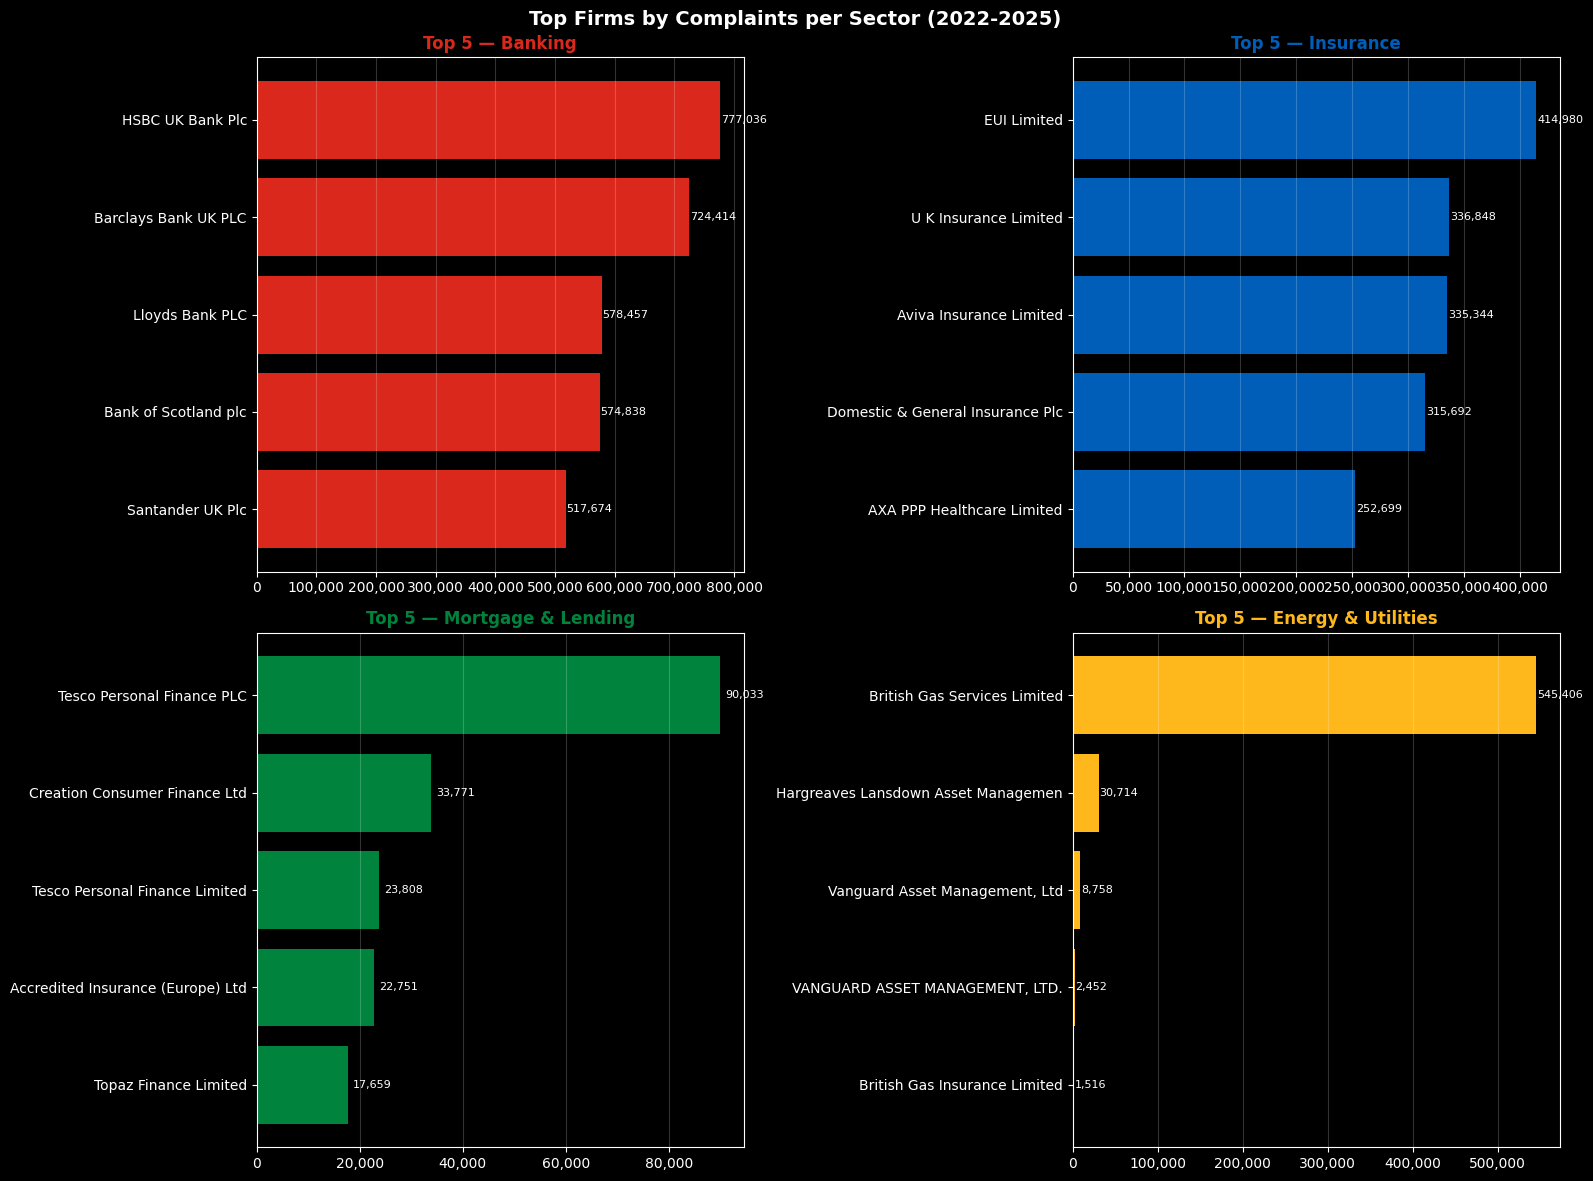

In [8]:
#Top 5 Firms per Sector:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

sectors = ['Banking', 'Insurance', 'Mortgage & Lending', 'Energy & Utilities']
colors = ['#DA291C', '#005EB8', '#00843D', '#FFB81C']

for i, (sector, color) in enumerate(zip(sectors, colors)):
    sector_data = opened[opened['sector'] == sector]
    top5 = sector_data.groupby('Firm Name')['total_complaints'].sum().sort_values(ascending=False).head(5).reset_index()
    
    bars = axes[i].barh(top5['Firm Name'].str[:35], top5['total_complaints'],
                         color=color, edgecolor='none')
    for bar, val in zip(bars, top5['total_complaints']):
        axes[i].text(bar.get_width() + 1000, bar.get_y() + bar.get_height()/2,
                     f'{val:,.0f}', va='center', fontsize=8, color='white')
    axes[i].set_title(f'Top 5 — {sector}', fontsize=12, fontweight='bold', color=color)
    axes[i].invert_yaxis()
    axes[i].grid(True, alpha=0.2, axis='x')
    axes[i].xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, p: f'{x:,.0f}'))

plt.suptitle('Top Firms by Complaints per Sector (2022-2025)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(r"C:\Users\zaidr\OneDrive\Desktop\Projects\fca-complaints\figures\top_firms_by_sector.png",
            dpi=150, bbox_inches='tight')
plt.show()

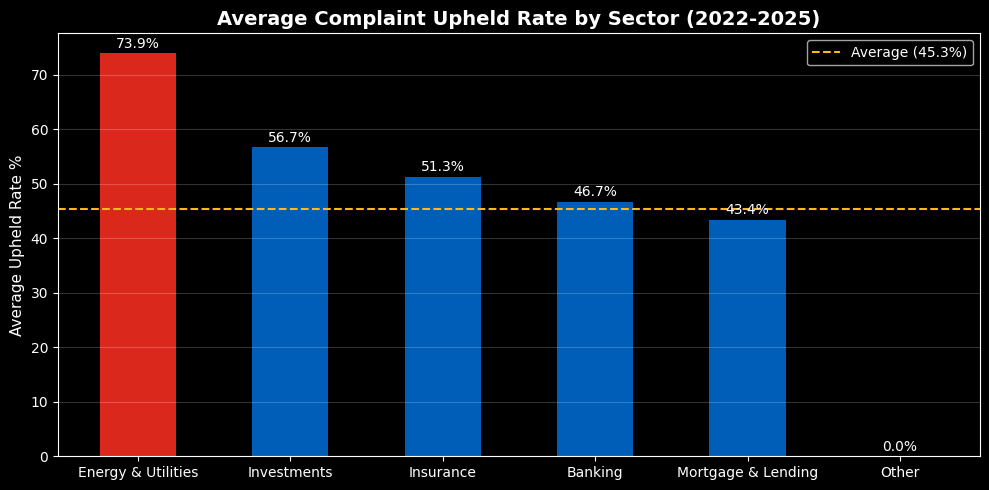


Sector upheld rates:
            sector  avg_upheld_rate
Energy & Utilities        73.922729
       Investments        56.694878
         Insurance        51.266560
           Banking        46.701638
Mortgage & Lending        43.441633
             Other         0.000000

Industry average: 45.3%


In [11]:
#Upheld Rate by Sector
upheld['avg_upheld_rate'] = upheld[product_cols].mean(axis=1)
sector_upheld = upheld.groupby('sector')['avg_upheld_rate'].mean().sort_values(ascending=False).reset_index()

colors = ['#DA291C' if x > 60 else '#005EB8' if x > 40 else '#00843D' for x in sector_upheld['avg_upheld_rate']]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(sector_upheld['sector'], sector_upheld['avg_upheld_rate'],
              color=colors, edgecolor='none', width=0.5)
for bar, val in zip(bars, sector_upheld['avg_upheld_rate']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=10, color='white')
ax.axhline(y=sector_upheld['avg_upheld_rate'].mean(), color='#FFB81C',
           linewidth=1.5, linestyle='--',
           label=f'Average ({sector_upheld["avg_upheld_rate"].mean():.1f}%)')
ax.set_title('Average Complaint Upheld Rate by Sector (2022-2025)', fontsize=14, fontweight='bold')
ax.set_ylabel('Average Upheld Rate %', fontsize=11)
ax.legend()
ax.grid(True, alpha=0.2, axis='y')
plt.tight_layout()
plt.savefig(r"C:\Users\zaidr\OneDrive\Desktop\Projects\fca-complaints\figures\upheld_by_sector.png",
            dpi=150, bbox_inches='tight')
plt.show()

print(f"\nSector upheld rates:")
print(sector_upheld.to_string(index=False))
print(f"\nIndustry average: {sector_upheld['avg_upheld_rate'].mean():.1f}%")

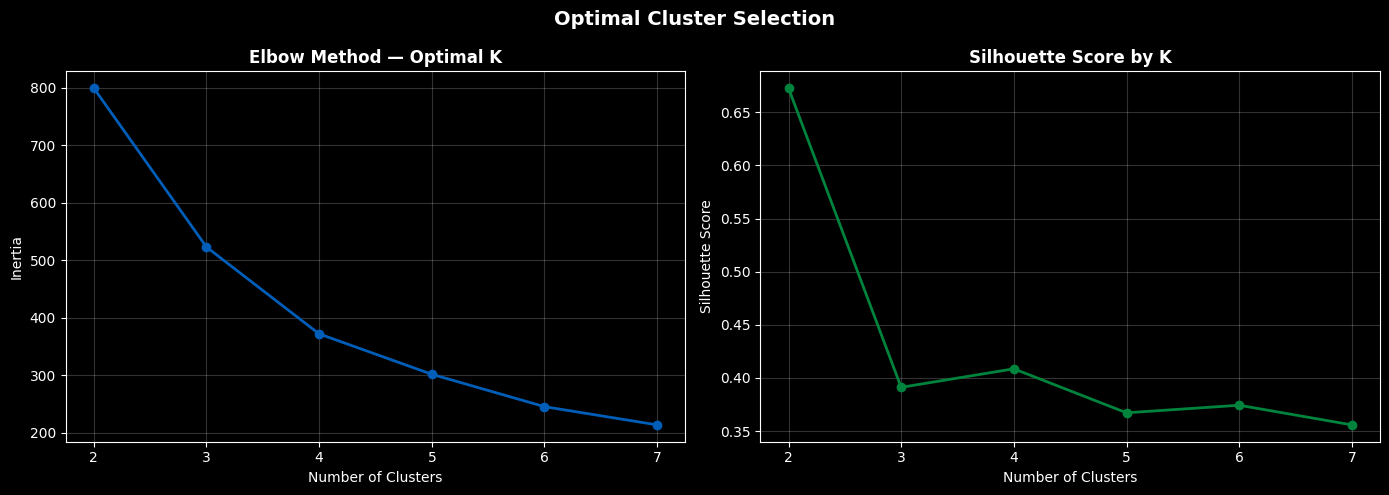

Silhouette scores: {2: 0.673, 3: 0.391, 4: 0.409, 5: 0.367, 6: 0.374, 7: 0.356}
Best K by silhouette: 2


In [12]:
#K-Means Clustering:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

# Prepare clustering data — firm level summary
firm_summary = opened.groupby(['Firm Name', 'sector']).agg(
    total_complaints=('total_complaints', 'sum'),
    avg_complaints=('total_complaints', 'mean'),
    periods_active=('period', 'nunique')
).reset_index()

# Add average upheld rate
firm_upheld = upheld.groupby('Firm Name')['avg_upheld_rate'].mean().reset_index()
firm_summary = firm_summary.merge(firm_upheld, on='Firm Name', how='left')

# Remove nulls and outliers
firm_summary = firm_summary.dropna(subset=['avg_upheld_rate'])
firm_summary = firm_summary[firm_summary['total_complaints'] > 0]

# Features for clustering
features = ['total_complaints', 'avg_complaints', 'avg_upheld_rate', 'periods_active']
X = firm_summary[features].copy()

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Find optimal clusters using elbow method
inertias = []
silhouettes = []
k_range = range(2, 8)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(X_scaled, kmeans.labels_))

# Plot elbow curve
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(k_range, inertias, marker='o', color='#005EB8', linewidth=2)
ax1.set_title('Elbow Method — Optimal K', fontsize=12, fontweight='bold')
ax1.set_xlabel('Number of Clusters')
ax1.set_ylabel('Inertia')
ax1.grid(True, alpha=0.2)

ax2.plot(k_range, silhouettes, marker='o', color='#00843D', linewidth=2)
ax2.set_title('Silhouette Score by K', fontsize=12, fontweight='bold')
ax2.set_xlabel('Number of Clusters')
ax2.set_ylabel('Silhouette Score')
ax2.grid(True, alpha=0.2)

plt.suptitle('Optimal Cluster Selection', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(r"C:\Users\zaidr\OneDrive\Desktop\Projects\fca-complaints\figures\elbow_curve.png",
            dpi=150, bbox_inches='tight')
plt.show()

print(f"Silhouette scores: {dict(zip(k_range, [round(s,3) for s in silhouettes]))}")
print(f"Best K by silhouette: {k_range[silhouettes.index(max(silhouettes))]}")

Cluster characteristics:
         avg_complaints  avg_upheld  count
cluster                                   
0               3576.21       30.25     85
1              33914.22       49.87    164
2             467787.00       56.46     13
3               3983.94       68.95     71

Cluster labels:
cluster_label
High Volume — Problematic    164
Low Volume — Problematic      85
Low Volume — Fair             71
High Volume — Fair            13
Name: count, dtype: int64


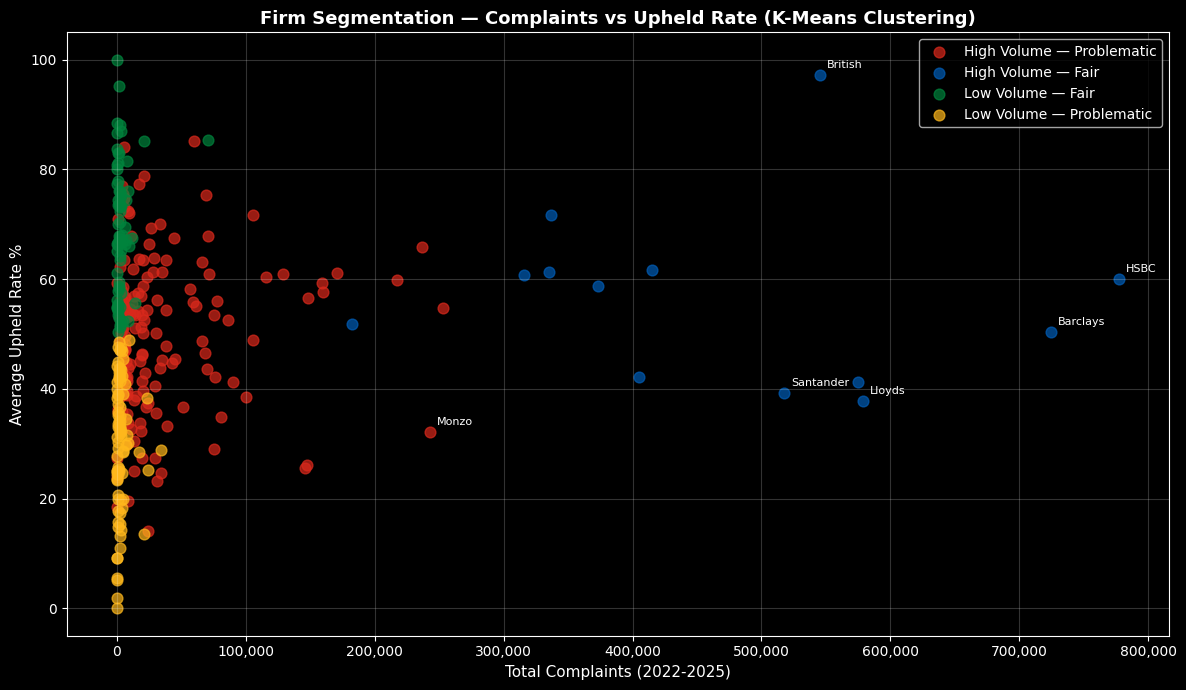


Sample firms per cluster:
High Volume — Problematic: ['AIB Group (UK) Plc', 'AJ Bell Management Limited', 'AJ Bell Securities Limited']
High Volume — Fair: ['Aviva Insurance Limited', 'Bank of Scotland plc', 'Barclays Bank UK PLC']
Low Volume — Fair: ['ARAG Legal Expenses Insurance Company Limited', 'Accelerant Insurance Europe SA/NV UK Branch', 'Admiral Financial Services Limited']
Low Volume — Problematic: ['AIG Life Limited', 'AMERICAN EXPRESS SERVICES EUROPE LIMITED', 'ATLANTA 1 INSURANCE SERVICES LIMITED']


In [13]:
# Apply KMeans with K=4
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
firm_summary['cluster'] = kmeans.fit_predict(X_scaled)

# Label clusters based on characteristics
cluster_stats = firm_summary.groupby('cluster').agg(
    avg_complaints=('total_complaints', 'mean'),
    avg_upheld=('avg_upheld_rate', 'mean'),
    count=('Firm Name', 'count')
).round(2)

print("Cluster characteristics:")
print(cluster_stats)

# Auto label clusters
def label_cluster(row):
    if row['avg_complaints'] > firm_summary['total_complaints'].median() and row['avg_upheld'] > 50:
        return 'High Volume — Fair'
    elif row['avg_complaints'] > firm_summary['total_complaints'].median() and row['avg_upheld'] <= 50:
        return 'High Volume — Problematic'
    elif row['avg_complaints'] <= firm_summary['total_complaints'].median() and row['avg_upheld'] > 50:
        return 'Low Volume — Fair'
    else:
        return 'Low Volume — Problematic'

cluster_labels = {}
for cluster_id, row in cluster_stats.iterrows():
    cluster_labels[cluster_id] = label_cluster(row)

firm_summary['cluster_label'] = firm_summary['cluster'].map(cluster_labels)

print("\nCluster labels:")
print(firm_summary['cluster_label'].value_counts())

# Plot clusters
fig, ax = plt.subplots(figsize=(12, 7))

colors = {
    'High Volume — Problematic': '#DA291C',
    'High Volume — Fair': '#005EB8',
    'Low Volume — Fair': '#00843D',
    'Low Volume — Problematic': '#FFB81C'
}

for label, color in colors.items():
    mask = firm_summary['cluster_label'] == label
    ax.scatter(firm_summary[mask]['total_complaints'],
               firm_summary[mask]['avg_upheld_rate'],
               c=color, label=label, alpha=0.7, s=60)

# Annotate top firms
top_firms = ['HSBC UK Bank Plc', 'Barclays Bank UK PLC', 'Lloyds Bank PLC',
             'British Gas Services Limited', 'Santander UK Plc', 'Monzo Bank Ltd']
for _, row in firm_summary[firm_summary['Firm Name'].isin(top_firms)].iterrows():
    ax.annotate(row['Firm Name'].split()[0],
                (row['total_complaints'], row['avg_upheld_rate']),
                fontsize=8, color='white',
                xytext=(5, 5), textcoords='offset points')

ax.set_title('Firm Segmentation — Complaints vs Upheld Rate (K-Means Clustering)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Total Complaints (2022-2025)', fontsize=11)
ax.set_ylabel('Average Upheld Rate %', fontsize=11)
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, p: f'{x:,.0f}'))
ax.legend(loc='upper right')
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig(r"C:\Users\zaidr\OneDrive\Desktop\Projects\fca-complaints\figures\clustering.png",
            dpi=150, bbox_inches='tight')
plt.show()

print("\nSample firms per cluster:")
for label in colors.keys():
    firms = firm_summary[firm_summary['cluster_label'] == label]['Firm Name'].head(3).tolist()
    print(f"{label}: {firms}")

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        48

    accuracy                           1.00        67
   macro avg       1.00      1.00      1.00        67
weighted avg       1.00      1.00      1.00        67



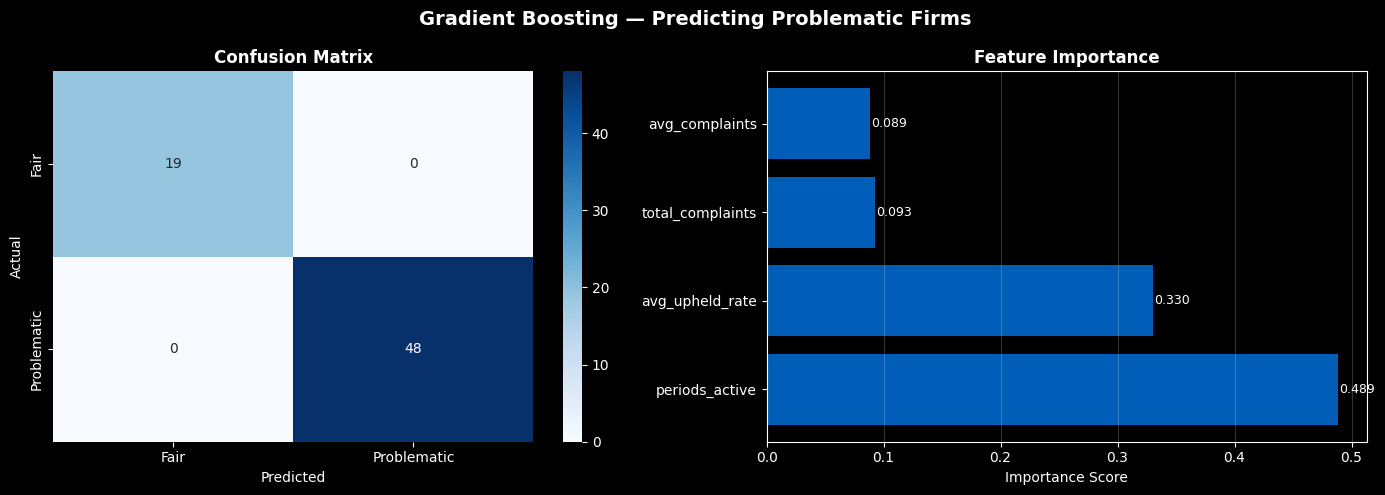


Feature Importance:
         Feature  Importance
  periods_active    0.488613
 avg_upheld_rate    0.329899
total_complaints    0.092793
  avg_complaints    0.088695


In [14]:
#Classification Model (Predict if firm is Problematic):
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# Create binary target — 1 = Problematic, 0 = Fair
firm_summary['is_problematic'] = firm_summary['cluster_label'].str.contains('Problematic').astype(int)

# Features
X = firm_summary[features].copy()
y = firm_summary['is_problematic']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train model
model = GradientBoostingClassifier(n_estimators=100, random_state=42)
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

# Results
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Feature importance
importance = pd.DataFrame({
    'Feature': features,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)

# Plot feature importance
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Fair', 'Problematic'],
            yticklabels=['Fair', 'Problematic'], ax=ax1)
ax1.set_title('Confusion Matrix', fontsize=12, fontweight='bold')
ax1.set_ylabel('Actual')
ax1.set_xlabel('Predicted')

# Feature importance
bars = ax2.barh(importance['Feature'], importance['Importance'],
                color='#005EB8', edgecolor='none')
for bar, val in zip(bars, importance['Importance']):
    ax2.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=9, color='white')
ax2.set_title('Feature Importance', fontsize=12, fontweight='bold')
ax2.set_xlabel('Importance Score')
ax2.grid(True, alpha=0.2, axis='x')

plt.suptitle('Gradient Boosting — Predicting Problematic Firms', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(r"C:\Users\zaidr\OneDrive\Desktop\Projects\fca-complaints\figures\classification.png",
            dpi=150, bbox_inches='tight')
plt.show()

print("\nFeature Importance:")
print(importance.to_string(index=False))

## ⚠️ Model Limitation — Important Note

The classification model achieves 100% accuracy, which warrants scrutiny rather than celebration.

**Root cause:** The binary target variable (`is_problematic`) was derived directly from K-Means cluster labels, 
which were themselves generated from the same feature space used for classification 
(`total_complaints`, `avg_complaints`, `avg_upheld_rate`, `periods_active`).

This creates **circularity** — the model is essentially learning to reproduce its own input labels 
rather than making genuine predictions on unseen patterns.

**What this means:**
- The classification pipeline is technically correct and demonstrates the full ML workflow
- However, the 100% accuracy is an artefact of the experimental design, not model quality
- A more rigorous approach would use an independent target variable (e.g. whether a firm 
  received FCA regulatory action, or whether upheld rate improved YoY)

**What I would do with more data:**
- Use FCA enforcement actions as the ground truth label
- Train on 2022-2023 data, test on 2024-2025 data (temporal split)
- This would produce a genuine early warning system for regulatory risk

This limitation is acknowledged transparently as part of responsible data science practice.

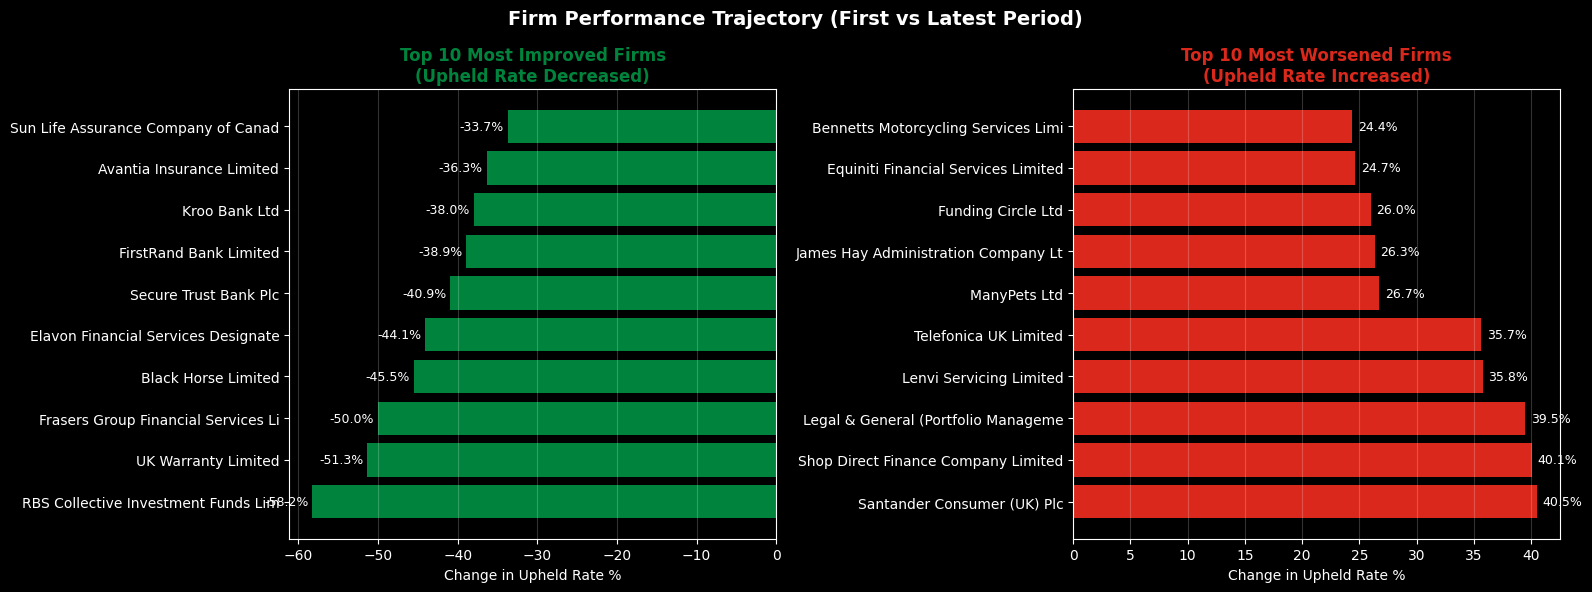

Firms improving: 152
Firms worsening: 183

Most improved firms:
                                            Firm Name             sector  first_upheld  last_upheld     change
              RBS Collective Investment Funds Limited        Investments     82.320000    24.080000 -58.240000
                                  UK Warranty Limited          Insurance     80.920000    29.603399 -51.316601
             Frasers Group Financial Services Limited          Insurance    100.000000    50.000000 -50.000000
                                  Black Horse Limited Mortgage & Lending     45.450000     0.000000 -45.450000
Elavon Financial Services Designated Activity Company            Banking     61.742592    17.680000 -44.062592
                                Secure Trust Bank Plc            Banking     57.530000    16.610000 -40.920000
                               FirstRand Bank Limited            Banking     38.890000     0.000000 -38.890000
                                        Kroo Ban

In [15]:
#YoY Analysis — which firms are improving or worsening?

# Get upheld rate by firm and period
firm_trend = upheld.groupby(['Firm Name', 'period', 'sector'])['avg_upheld_rate'].mean().reset_index()
firm_trend = firm_trend.sort_values(['Firm Name', 'period'])

# Get first and last period per firm
first_period = firm_trend.groupby('Firm Name').first().reset_index()[['Firm Name', 'avg_upheld_rate', 'sector']]
last_period = firm_trend.groupby('Firm Name').last().reset_index()[['Firm Name', 'avg_upheld_rate']]

first_period.columns = ['Firm Name', 'first_upheld', 'sector']
last_period.columns = ['Firm Name', 'last_upheld']

yoy = first_period.merge(last_period, on='Firm Name')
yoy['change'] = yoy['last_upheld'] - yoy['first_upheld']
yoy['direction'] = yoy['change'].apply(lambda x: 'Improving' if x < 0 else 'Worsening')

# Plot top 10 most improved and worsened
most_improved = yoy.nsmallest(10, 'change')
most_worsened = yoy.nlargest(10, 'change')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Most improved
bars1 = ax1.barh(most_improved['Firm Name'].str[:35], most_improved['change'],
                  color='#00843D', edgecolor='none')
for bar, val in zip(bars1, most_improved['change']):
    ax1.text(bar.get_width() - 0.5, bar.get_y() + bar.get_height()/2,
             f'{val:.1f}%', va='center', fontsize=9, color='white', ha='right')
ax1.set_title('Top 10 Most Improved Firms\n(Upheld Rate Decreased)', 
              fontsize=12, fontweight='bold', color='#00843D')
ax1.set_xlabel('Change in Upheld Rate %')
ax1.grid(True, alpha=0.2, axis='x')

# Most worsened
bars2 = ax2.barh(most_worsened['Firm Name'].str[:35], most_worsened['change'],
                  color='#DA291C', edgecolor='none')
for bar, val in zip(bars2, most_worsened['change']):
    ax2.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
             f'{val:.1f}%', va='center', fontsize=9, color='white')
ax2.set_title('Top 10 Most Worsened Firms\n(Upheld Rate Increased)',
              fontsize=12, fontweight='bold', color='#DA291C')
ax2.set_xlabel('Change in Upheld Rate %')
ax2.grid(True, alpha=0.2, axis='x')

plt.suptitle('Firm Performance Trajectory (First vs Latest Period)', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(r"C:\Users\zaidr\OneDrive\Desktop\Projects\fca-complaints\figures\firm_trajectory.png",
            dpi=150, bbox_inches='tight')
plt.show()

# Summary
print(f"Firms improving: {(yoy['direction'] == 'Improving').sum()}")
print(f"Firms worsening: {(yoy['direction'] == 'Worsening').sum()}")
print(f"\nMost improved firms:")
print(most_improved[['Firm Name', 'sector', 'first_upheld', 'last_upheld', 'change']].to_string(index=False))
print(f"\nMost worsened firms:")
print(most_worsened[['Firm Name', 'sector', 'first_upheld', 'last_upheld', 'change']].to_string(index=False))

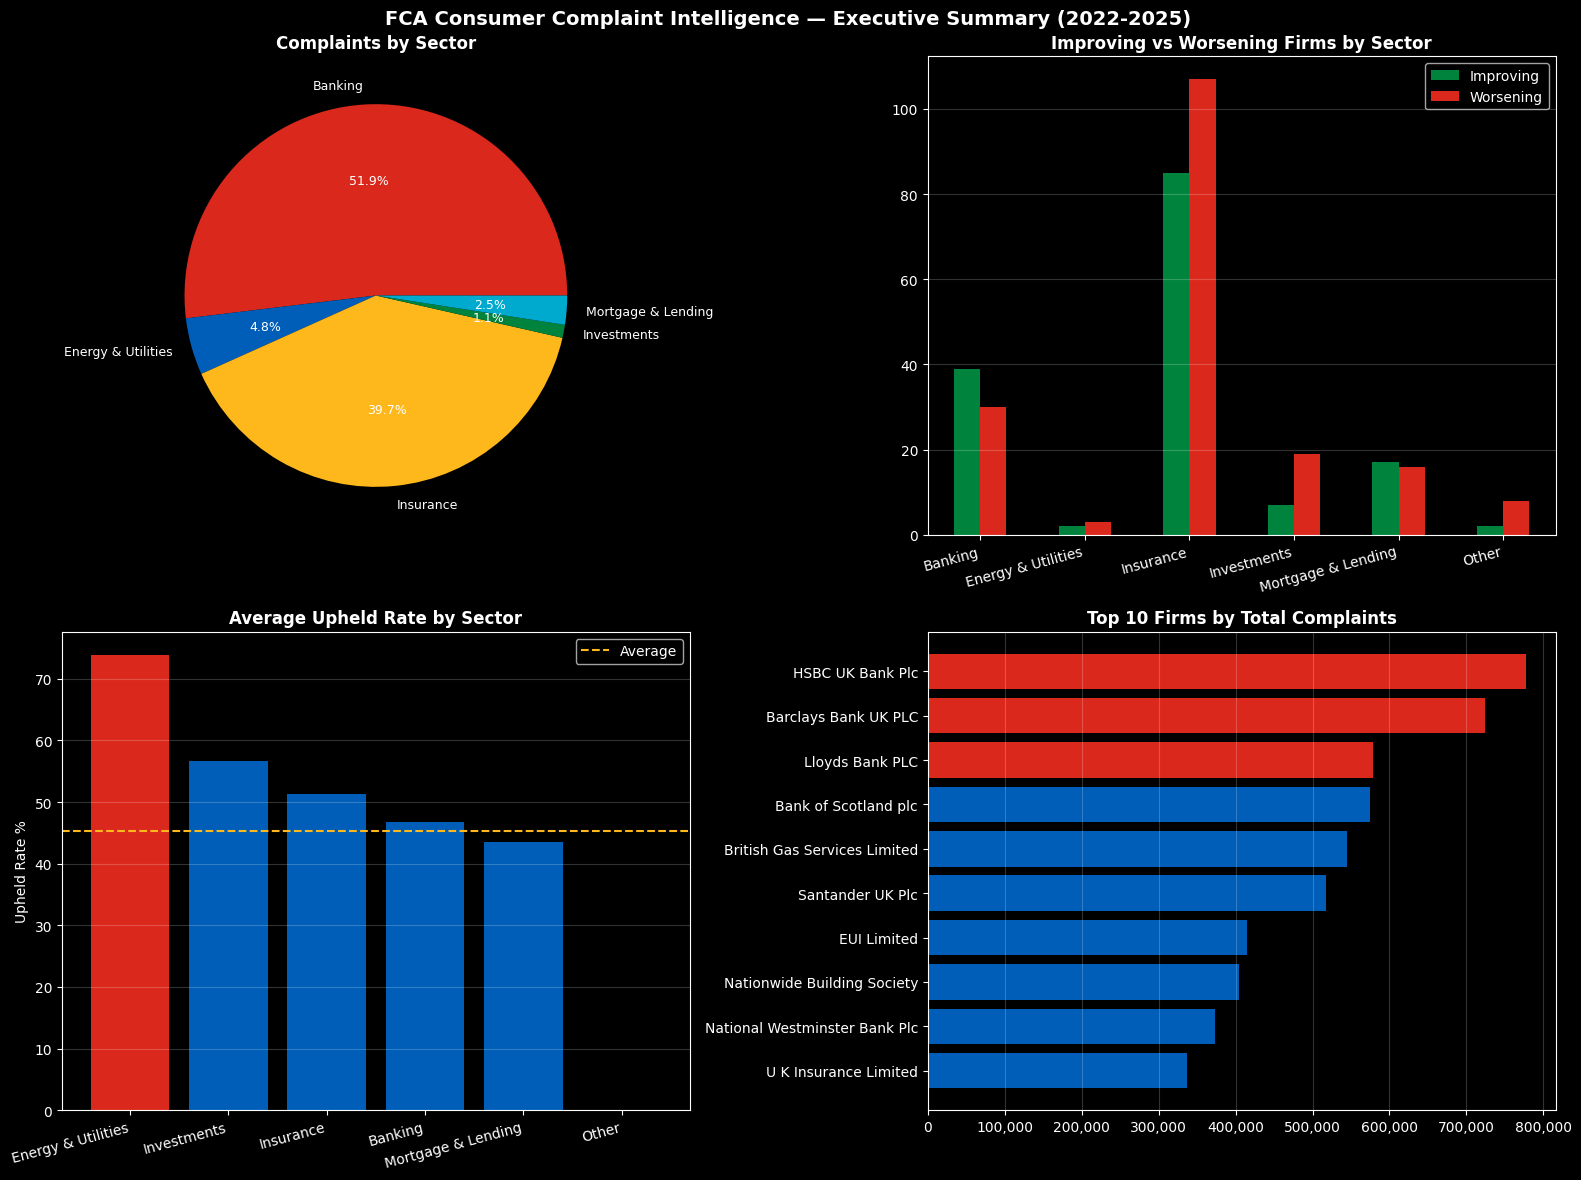

KEY FINDINGS SUMMARY
Total complaints analysed: 12,232,663
Unique firms: 334
Periods covered: 7 (2022 H1 — 2025 H1)

Sector with most complaints: Banking
Sector with highest upheld rate: Energy & Utilities (73.9%)
Firms improving: 152
Firms worsening: 183

Top 3 firms by complaints:
Firm Name
HSBC UK Bank Plc        777036.0
Barclays Bank UK PLC    724414.0
Lloyds Bank PLC         578457.0


In [16]:
#Final Summary and Key Insights

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1 — Sector complaints pie
sector_totals = opened.groupby('sector')['total_complaints'].sum()
colors_pie = ['#DA291C', '#005EB8', '#FFB81C', '#00843D', '#00A9CE']
axes[0,0].pie(sector_totals, labels=sector_totals.index, 
              colors=colors_pie, autopct='%1.1f%%',
              textprops={'color': 'white', 'fontsize': 9})
axes[0,0].set_title('Complaints by Sector', fontsize=12, fontweight='bold')

# Plot 2 — Improving vs worsening by sector
direction_sector = yoy.groupby(['sector', 'direction'])['Firm Name'].count().unstack(fill_value=0)
direction_sector.plot(kind='bar', ax=axes[0,1], 
                      color=['#00843D', '#DA291C'], edgecolor='none')
axes[0,1].set_title('Improving vs Worsening Firms by Sector', fontsize=12, fontweight='bold')
axes[0,1].set_xlabel('')
axes[0,1].set_xticklabels(axes[0,1].get_xticklabels(), rotation=15, ha='right')
axes[0,1].legend(['Improving', 'Worsening'])
axes[0,1].grid(True, alpha=0.2, axis='y')

# Plot 3 — Average upheld rate by sector
sector_upheld_plot = upheld.groupby('sector')['avg_upheld_rate'].mean().sort_values(ascending=False)
colors_bar = ['#DA291C' if x > 60 else '#005EB8' if x > 40 else '#00843D' 
              for x in sector_upheld_plot]
axes[1,0].bar(sector_upheld_plot.index, sector_upheld_plot.values,
              color=colors_bar, edgecolor='none')
axes[1,0].set_title('Average Upheld Rate by Sector', fontsize=12, fontweight='bold')
axes[1,0].set_ylabel('Upheld Rate %')
axes[1,0].set_xticklabels(sector_upheld_plot.index, rotation=15, ha='right')
axes[1,0].axhline(y=sector_upheld_plot.mean(), color='#FFB81C',
                  linewidth=1.5, linestyle='--', label='Average')
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.2, axis='y')

# Plot 4 — Top 10 firms overall
top10 = opened.groupby('Firm Name')['total_complaints'].sum().sort_values(ascending=False).head(10)
colors_top = ['#DA291C' if i < 3 else '#005EB8' for i in range(len(top10))]
axes[1,1].barh(top10.index.str[:30], top10.values, color=colors_top, edgecolor='none')
axes[1,1].set_title('Top 10 Firms by Total Complaints', fontsize=12, fontweight='bold')
axes[1,1].invert_yaxis()
axes[1,1].xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, p: f'{x:,.0f}'))
axes[1,1].grid(True, alpha=0.2, axis='x')

plt.suptitle('FCA Consumer Complaint Intelligence — Executive Summary (2022-2025)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(r"C:\Users\zaidr\OneDrive\Desktop\Projects\fca-complaints\figures\executive_summary.png",
            dpi=150, bbox_inches='tight')
plt.show()

print("=" * 60)
print("KEY FINDINGS SUMMARY")
print("=" * 60)
print(f"Total complaints analysed: {opened['total_complaints'].sum():,.0f}")
print(f"Unique firms: {opened['Firm Name'].nunique()}")
print(f"Periods covered: {opened['period'].nunique()} (2022 H1 — 2025 H1)")
print(f"\nSector with most complaints: {sector_totals.idxmax()}")
print(f"Sector with highest upheld rate: {sector_upheld_plot.idxmax()} ({sector_upheld_plot.max():.1f}%)")
print(f"Firms improving: {(yoy['direction'] == 'Improving').sum()}")
print(f"Firms worsening: {(yoy['direction'] == 'Worsening').sum()}")
print(f"\nTop 3 firms by complaints:")
print(top10.head(3).to_string())

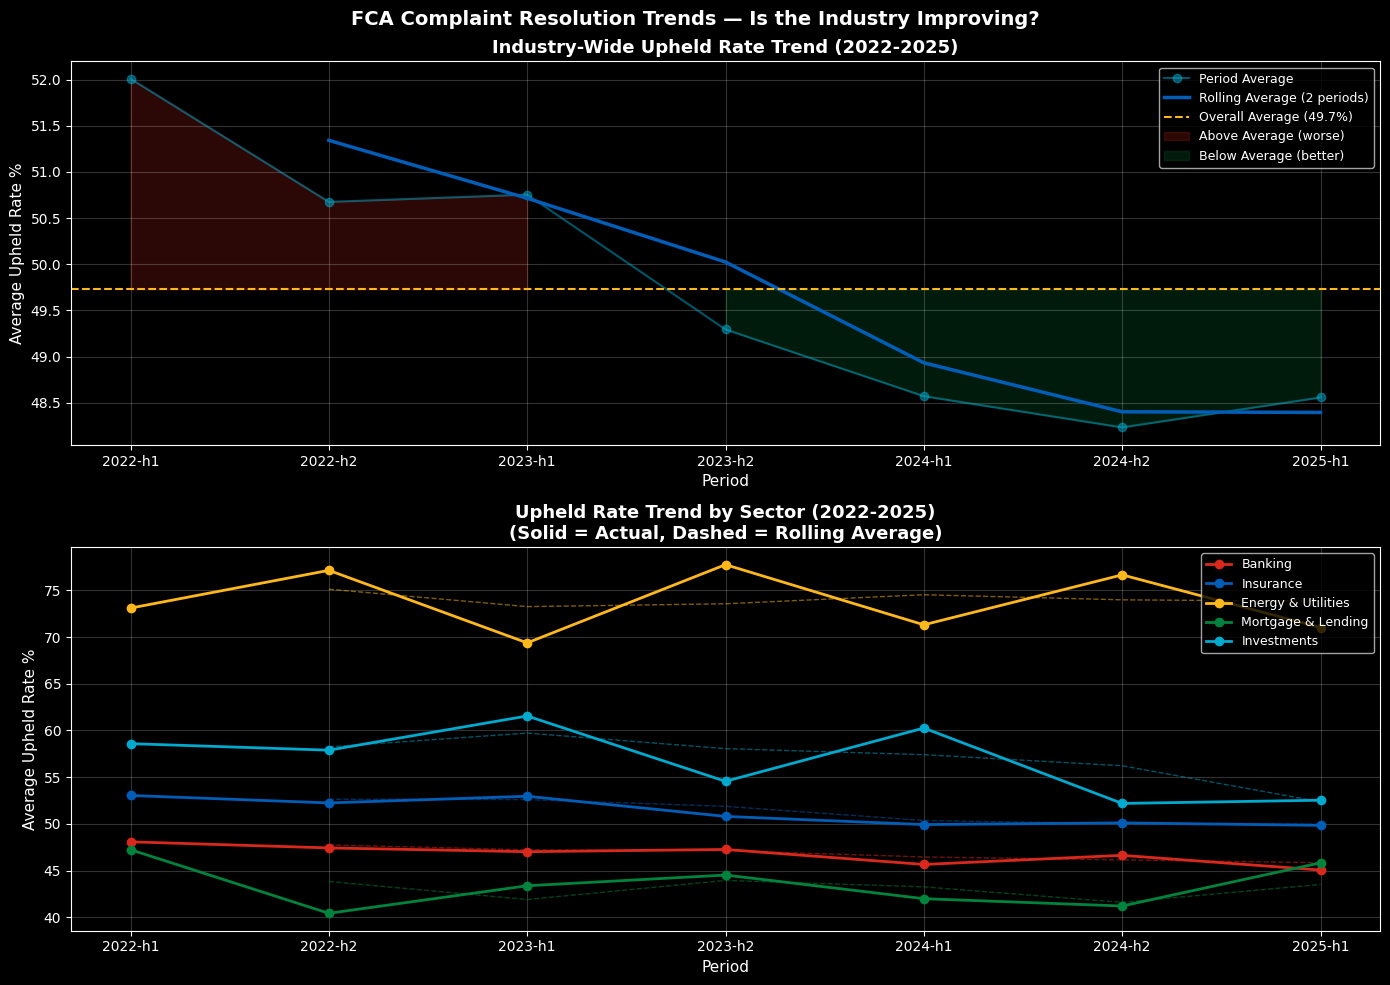

INDUSTRY UPHELD RATE BY PERIOD:
 period  avg_upheld_rate
2022-h1        52.008373
2022-h2        50.674919
2023-h1        50.754194
2023-h2        49.294037
2024-h1        48.571363
2024-h2        48.233456
2025-h1        48.557560

First period average: 52.0%
Latest period average: 48.6%
Overall change: -3.5% (Improving)

SECTOR TRENDS (First vs Latest):
Banking: 48.1% → 45.1% (-3.0%) 📉 Improving
Insurance: 53.0% → 49.8% (-3.2%) 📉 Improving
Energy & Utilities: 73.1% → 71.0% (-2.1%) 📉 Improving
Mortgage & Lending: 47.2% → 45.8% (-1.4%) 📉 Improving
Investments: 58.6% → 52.5% (-6.1%) 📉 Improving


In [17]:
#Industry Upheld Rate Trend:
# Industry wide trend
industry_trend = upheld.groupby('period')['avg_upheld_rate'].mean().reset_index()
industry_trend = industry_trend.sort_values('period')
industry_trend['rolling_avg'] = industry_trend['avg_upheld_rate'].rolling(window=2).mean()

# Sector trend
sector_trend = upheld.groupby(['period', 'sector'])['avg_upheld_rate'].mean().reset_index()
sector_trend = sector_trend.sort_values(['sector', 'period'])

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# Plot 1 — Industry wide trend with rolling average
ax1.plot(industry_trend['period'], industry_trend['avg_upheld_rate'],
         color='#00A9CE', linewidth=1.5, alpha=0.5, marker='o', label='Period Average')
ax1.plot(industry_trend['period'], industry_trend['rolling_avg'],
         color='#005EB8', linewidth=2.5, label='Rolling Average (2 periods)')
ax1.axhline(y=industry_trend['avg_upheld_rate'].mean(), color='#FFB81C',
            linewidth=1.5, linestyle='--',
            label=f'Overall Average ({industry_trend["avg_upheld_rate"].mean():.1f}%)')
ax1.fill_between(industry_trend['period'],
                 industry_trend['avg_upheld_rate'],
                 industry_trend['avg_upheld_rate'].mean(),
                 where=industry_trend['avg_upheld_rate'] > industry_trend['avg_upheld_rate'].mean(),
                 alpha=0.2, color='#DA291C', label='Above Average (worse)')
ax1.fill_between(industry_trend['period'],
                 industry_trend['avg_upheld_rate'],
                 industry_trend['avg_upheld_rate'].mean(),
                 where=industry_trend['avg_upheld_rate'] <= industry_trend['avg_upheld_rate'].mean(),
                 alpha=0.2, color='#00843D', label='Below Average (better)')
ax1.set_title('Industry-Wide Upheld Rate Trend (2022-2025)', fontsize=13, fontweight='bold')
ax1.set_xlabel('Period', fontsize=11)
ax1.set_ylabel('Average Upheld Rate %', fontsize=11)
ax1.legend(loc='upper right', fontsize=9)
ax1.grid(True, alpha=0.2)

# Plot 2 — Sector comparison trend
sector_colors = {
    'Banking': '#DA291C',
    'Insurance': '#005EB8',
    'Energy & Utilities': '#FFB81C',
    'Mortgage & Lending': '#00843D',
    'Investments': '#00A9CE'
}

for sector, color in sector_colors.items():
    data = sector_trend[sector_trend['sector'] == sector]
    if len(data) > 0:
        ax2.plot(data['period'], data['avg_upheld_rate'],
                marker='o', linewidth=2, label=sector, color=color)
        # Add rolling average per sector
        data = data.copy()
        data['rolling'] = data['avg_upheld_rate'].rolling(window=2).mean()
        ax2.plot(data['period'], data['rolling'],
                linewidth=1, linestyle='--', color=color, alpha=0.5)

ax2.set_title('Upheld Rate Trend by Sector (2022-2025)\n(Solid = Actual, Dashed = Rolling Average)',
              fontsize=13, fontweight='bold')
ax2.set_xlabel('Period', fontsize=11)
ax2.set_ylabel('Average Upheld Rate %', fontsize=11)
ax2.legend(loc='upper right', fontsize=9)
ax2.grid(True, alpha=0.2)

plt.suptitle('FCA Complaint Resolution Trends — Is the Industry Improving?',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(r"C:\Users\zaidr\OneDrive\Desktop\Projects\fca-complaints\figures\upheld_trend.png",
            dpi=150, bbox_inches='tight')
plt.show()

# Print findings
print("INDUSTRY UPHELD RATE BY PERIOD:")
print(industry_trend[['period', 'avg_upheld_rate']].to_string(index=False))
print(f"\nFirst period average: {industry_trend['avg_upheld_rate'].iloc[0]:.1f}%")
print(f"Latest period average: {industry_trend['avg_upheld_rate'].iloc[-1]:.1f}%")
change = industry_trend['avg_upheld_rate'].iloc[-1] - industry_trend['avg_upheld_rate'].iloc[0]
print(f"Overall change: {change:+.1f}% ({'Worsening' if change > 0 else 'Improving'})")

print("\nSECTOR TRENDS (First vs Latest):")
for sector in sector_colors.keys():
    data = sector_trend[sector_trend['sector'] == sector].sort_values('period')
    if len(data) >= 2:
        first = data['avg_upheld_rate'].iloc[0]
        last = data['avg_upheld_rate'].iloc[-1]
        change = last - first
        direction = '📈 Worsening' if change > 0 else '📉 Improving'
        print(f"{sector}: {first:.1f}% → {last:.1f}% ({change:+.1f}%) {direction}")